In [130]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

from torchvision.transforms import v2

# Import data and transform it

In [131]:
# https://www.geeksforgeeks.org/machine-learning/implement-deep-autoencoder-in-pytorch-for-image-reconstruction/

#https://medium.com/@kdk199604/patchcore-rethinking-cold-start-industrial-anomaly-detection-with-patch-level-memory-c2d62678365b

In [132]:
name_dataset = "bottle"

In [133]:
train_path = name_dataset + "/train/"
test_path = name_dataset + "/test/"

In [134]:
%pwd

'/Users/joaofranciscoviana/mega/DataScienceProjects/Project_Anomaly_Detection'

Training classes ['good']
Test classes ['broken_large', 'broken_small', 'contamination', 'good']


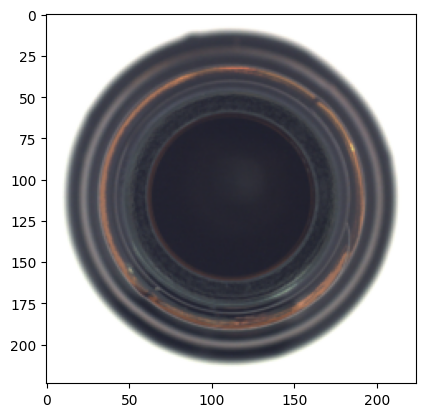

In [135]:
img_size = 224
num_colous = 3

transform = transforms.Compose([
transforms.Resize((img_size, img_size)),
transforms.ToTensor()])
    

train_images = torchvision.datasets.ImageFolder(train_path, transform=transform)
print("Training classes", train_images.classes)
test_images = torchvision.datasets.ImageFolder(test_path, transform=transform)
print("Test classes", test_images.classes)
plt.imshow(train_images[0][0].permute(1, 2, 0), cmap='gray')

plt.show()

In [136]:
device = torch.device("mps")

In [137]:
torch.manual_seed(42)
loader_train = DataLoader(train_images, batch_size=4, shuffle=True, num_workers=0)
loader_test = DataLoader(test_images, num_workers=1)

# Test the models

In [138]:
def loss_img(img, model, flatten=False):
    img = img.reshape(3, img_size, img_size)          

    if flatten:
        x = img.reshape(-1, num_colours * img_size * img_size)   
    else:
        x = img.unsqueeze(0)                                     

    with torch.no_grad():
        predicted_img = model(x).detach()

    predicted_img = predicted_img.reshape(3, img_size, img_size)
    return criterion(predicted_img, img)


def compare_img(img, model, flatten=False):
    fig, ax = plt.subplots(1, 3, figsize=(12, 8))
    img = img.reshape(3, img_size, img_size)

    if flatten:
        x = img.reshape(-1, 3 * img_size * img_size)
    else:
        x = img.unsqueeze(0)

    with torch.no_grad():
        predicted_img = model(x).detach().clamp(0, 1)

    predicted_img = predicted_img.reshape(3, img_size, img_size)

    img = img.permute(1, 2, 0)
    predicted_img = predicted_img.permute(1, 2, 0)
    ax[0].imshow(img)
    ax[1].imshow(predicted_img)
    ax[2].imshow((img - predicted_img).abs().sum(-1), cmap="inferno")

# Models

## Convolution autoencoder

In [139]:
# Writing our model
class Autoencoder_000(nn.Module):
    def __init__(self):
        super(Autoencoder_000,self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(True),
            nn.Conv2d(6, 6, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(True),
            nn.Conv2d(6, 6, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(True),
            nn.Conv2d(6, 2, kernel_size=5), nn.BatchNorm2d(2), nn.ELU(True))
        self.decoder = nn.Sequential(             
            nn.ConvTranspose2d(2, 6, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(True),
            nn.ConvTranspose2d(6, 6, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(True),
            nn.ConvTranspose2d(6, 6, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(True),
            nn.ConvTranspose2d(6, 3, kernel_size=5),
            torch.nn.Sigmoid())
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [140]:
# Writing our model from claude
class Autoencoder_001(nn.Module):
    def __init__(self):
        super(Autoencoder_001,self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3,  32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ELU(True),  # 32→16
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ELU(True),  # 16→8
            nn.Conv2d(64, 2,  3, stride=1, padding=1))                                     # no BN/act
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2,  64, 3, stride=1, padding=1), nn.BatchNorm2d(64), nn.ELU(True),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32), nn.ELU(True),
            nn.ConvTranspose2d(32, 3,  3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid())
        
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [141]:
# Writing our model
class Autoencoder_002(nn.Module):
    def __init__(self):
        super(Autoencoder_002,self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 6, stride=2, padding=1, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(inplace=True),
            nn.Conv2d(6, 6, stride=2, padding=1, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(inplace=True),
            nn.Conv2d(6, 6, stride=2, padding=1, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(inplace=True),
            nn.Conv2d(6, 2, stride=1, padding=1, kernel_size=5), nn.BatchNorm2d(2), nn.ELU(inplace=True))
        self.decoder = nn.Sequential(             
            nn.ConvTranspose2d(2, 6, padding=1, stride=1, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(inplace=True),
            nn.ConvTranspose2d(6, 6, padding=1, stride=2, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(inplace=True),
            nn.ConvTranspose2d(6, 6, padding=1, stride=2, kernel_size=5), nn.BatchNorm2d(6), nn.ELU(inplace=True),
            nn.ConvTranspose2d(6, 3, padding=1, stride=2, kernel_size=5, output_padding=1),
            torch.nn.Sigmoid())
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [142]:
class Autoencoder_003(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,  32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ELU(), 
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ELU(),  
            nn.Conv2d(64, 2,  3, stride=1, padding=1))                               
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2,  64, 3, stride=1, padding=1), nn.BatchNorm2d(64), nn.ELU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ELU(),  
            nn.ConvTranspose2d(32, 3,  4, stride=2, padding=1),                                
            nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [143]:
class Autoencoder_004(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,  32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ELU(), 
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ELU(),  
            nn.Conv2d(64, 2,  3, stride=3, padding=1), nn.BatchNorm2d(2), nn.ELU())
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(2,  64, 3, stride=3, padding=1, output_padding=1), nn.BatchNorm2d(64), nn.ELU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ELU(),  
            nn.ConvTranspose2d(32, 3,  4, stride=2, padding=1),                                
            nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [144]:
class Autoencoder_005(nn.Module):
    def __init__(self):
        super(Autoencoder_005, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(16, 8, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 3, stride=2,
                               padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2,
                               padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [145]:
model_folder = name_dataset + "_models"

models = [Autoencoder_000, Autoencoder_001, Autoencoder_002, Autoencoder_003, Autoencoder_004, Autoencoder_005]

criterion = torch.nn.MSELoss()
num_epochs = 100

In [146]:
train_loss_list = []
trained_models = []

for cls in models:
    torch.manual_seed(42)
    model = cls().to(device)
    model.to(device)
    model.train()
    name = type(model).__name__

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # List that will store the training loss
    min_loss = 1e100
    train_loss = []
    
    # Training loop starts
    for epoch in tqdm(range(num_epochs), desc=name):
          
        # Initializing variable for storing 
        # loss
        running_loss = 0
        
        # Iterating over the training dataset
        for batch in loader_train:
            img, _ = batch
            
            # Generating output
            img = img.to(device)
            out = model(img)
            
            # Calculating loss
            loss = criterion(out, img)
            
            # Updating weights according
            # to the calculated loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Incrementing loss
            running_loss += loss.item() * img.size(0)
        
        # Averaging out loss over entire batch
        running_loss /= len(loader_train.dataset)
        train_loss.append(running_loss)

        if running_loss < min_loss:
            min_loss = running_loss
            torch.save({"epoch": num_epochs - 1,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "val_loss": running_loss},
                f"{model_folder}/{name}.pt")
            

    train_loss_list.append(train_loss)

Autoencoder_000:   0%|          | 0/100 [00:00<?, ?it/s]

Autoencoder_001:   0%|          | 0/100 [00:00<?, ?it/s]

Autoencoder_002:   0%|          | 0/100 [00:00<?, ?it/s]

Autoencoder_003:   0%|          | 0/100 [00:00<?, ?it/s]

Autoencoder_004:   0%|          | 0/100 [00:00<?, ?it/s]

Autoencoder_005:   0%|          | 0/100 [00:00<?, ?it/s]

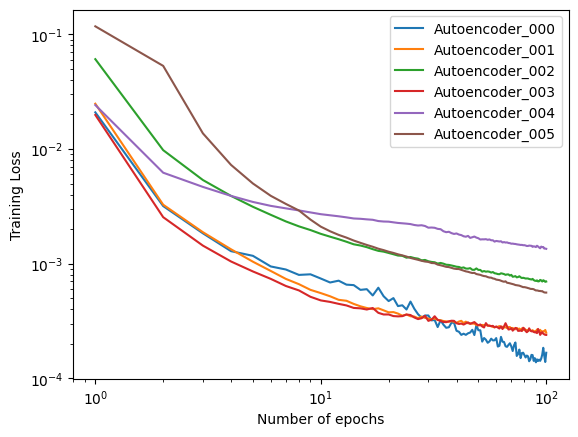

In [147]:
for i in range(len(train_loss_list)):

    # Plotting the training loss
    plt.plot(range(1,num_epochs+1), train_loss_list[i], label=models[i].__name__)

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of epochs")
plt.ylabel("Training Loss")
plt.show()

# Results

In [148]:
models = [Autoencoder_000, Autoencoder_001, Autoencoder_002, Autoencoder_003, Autoencoder_004, Autoencoder_005]

trained_models = []

In [149]:
def load_model(cls, device=device):
    ck = torch.load(f"{model_folder}/{cls.__name__}.pt",
                    map_location=device, weights_only=True)
    m = cls().to(device)
    m.load_state_dict(ck["model_state"])
    m.eval()
    return m, ck

In [150]:
results = []
for cls in models:
    model, ck = load_model(cls)
    modelname = cls.__name__
    print(cls.__name__, " | loss =", ck["val_loss"], "| at epoch", ck["epoch"])
    model_result = {"name" : modelname}

    trained_models.append(model)

    loss_list = []
    class_list = []

    for cla in test_images.classes:
        idx = test_images.class_to_idx[cla]
        indices = [i for i, t in enumerate(test_images.targets) if t == idx]

        img_list=[]
        
        for i in indices:
            img = test_images[i][0].unsqueeze(0).to(device)
            img_class = test_images[i][1]
            model.eval()
            loss_list.append(loss_img(img, model).cpu().numpy())
            class_list.append(img_class)
            img_list.append(img.to("cpu"))
    
        model_result[cla + "_img"] = img_list 

    loss_list = np.array(loss_list)
    loss_list /= loss_list.max()
    class_list = np.array(class_list)
    anomaly_true_list = 1 - np.floor(class_list/class_list.max())

    fpr, tpr, thresholds = roc_curve(anomaly_true_list, loss_list)
    roc_auc = auc(fpr, tpr)

    model_result["auc"] = roc_auc
    model_result["fpr"] = fpr
    model_result["tpr"] = tpr

    results.append(model_result)
    
        


Autoencoder_000  | loss = 0.00013810506607985133 | at epoch 99
Autoencoder_001  | loss = 0.0002501847022758913 | at epoch 99
Autoencoder_002  | loss = 0.0006951017652829869 | at epoch 99
Autoencoder_003  | loss = 0.00023949670849889338 | at epoch 99
Autoencoder_004  | loss = 0.0013482911104523536 | at epoch 99
Autoencoder_005  | loss = 0.0005601488697703518 | at epoch 99


In [ ]:
print(tabulate(table))

In [163]:

print(tabulate([[r["name"], r["auc"]] for r in results], headers=["model", "AUC"]))

model                 AUC
---------------  --------
Autoencoder_000  0.721429
Autoencoder_001  0.599206
Autoencoder_002  0.802381
Autoencoder_003  0.61746
Autoencoder_004  0.719841
Autoencoder_005  0.562698


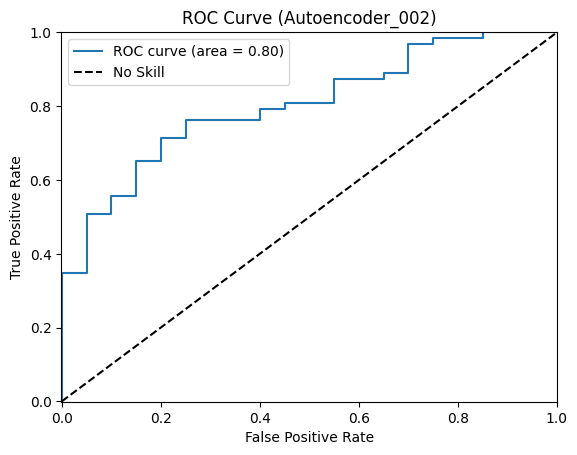

In [165]:
model_index = 2
plt.figure()  
plt.plot(results[model_index]["fpr"], results[model_index]["tpr"], label='ROC curve (area = %0.2f)' %  results[model_index]["auc"])
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([-0.001, 1.001])
plt.ylim([-0.001, 1.001])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Autoencoder_002)')
plt.legend()
plt.show()

## DeepAutoEncoder

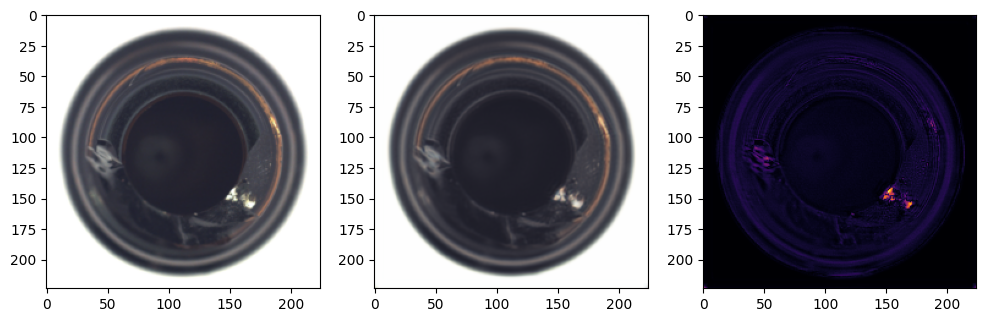

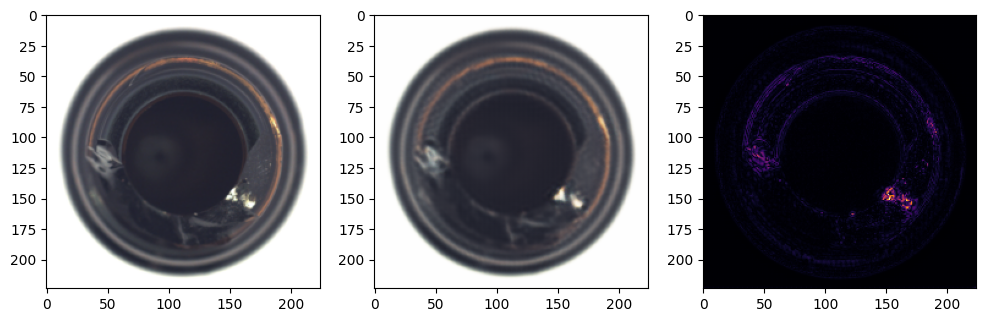

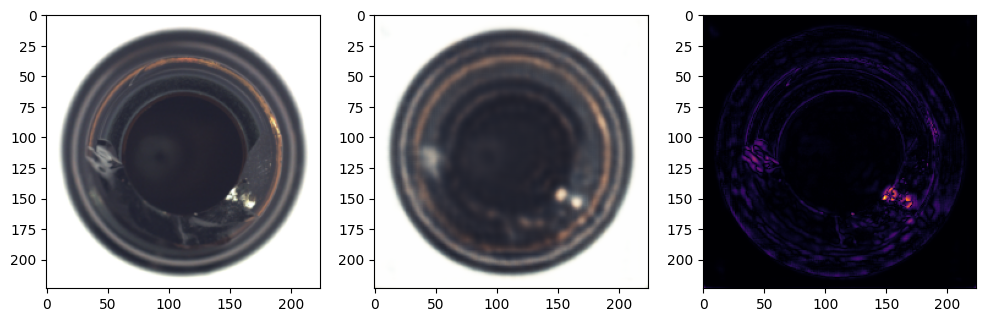

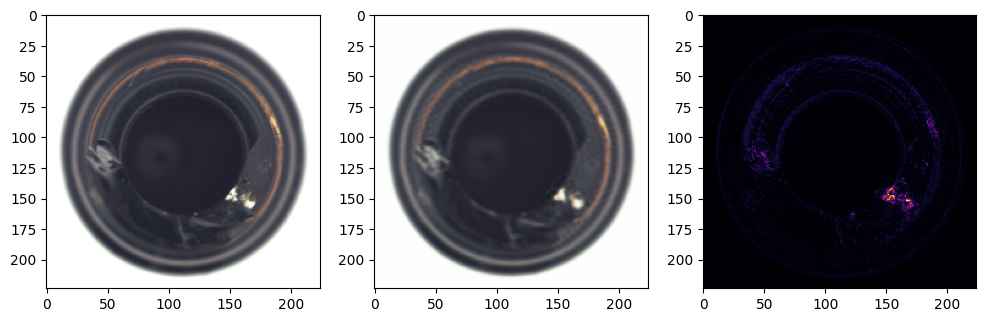

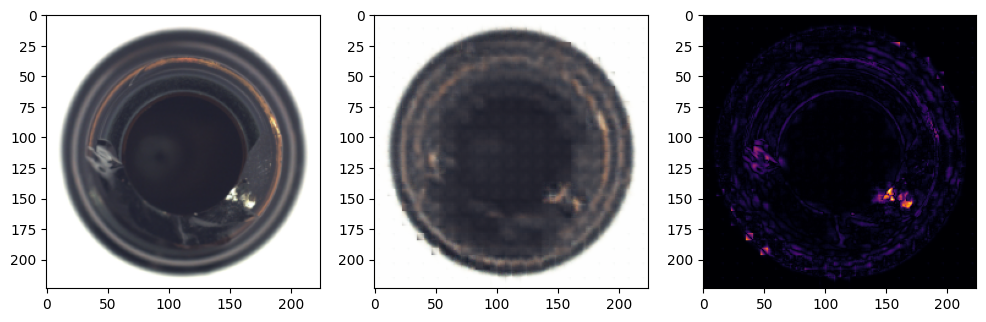

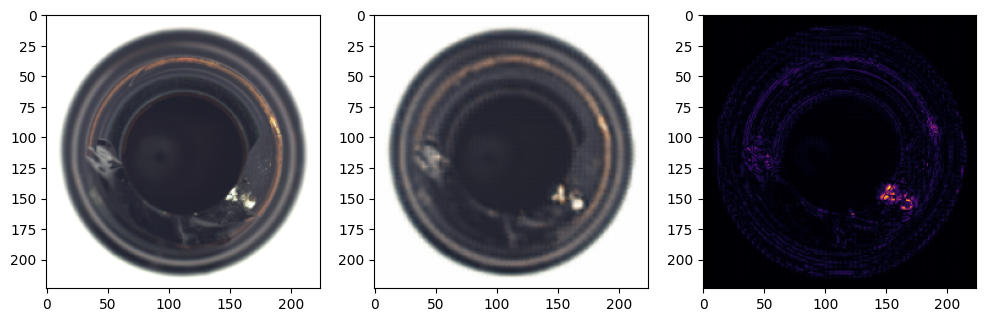

In [155]:
for trained_model in trained_models:
    compare_img(test_images[1][0], trained_model.cpu())

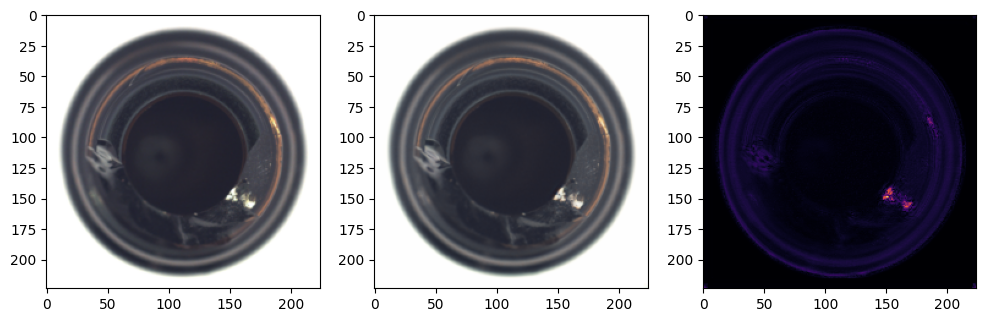

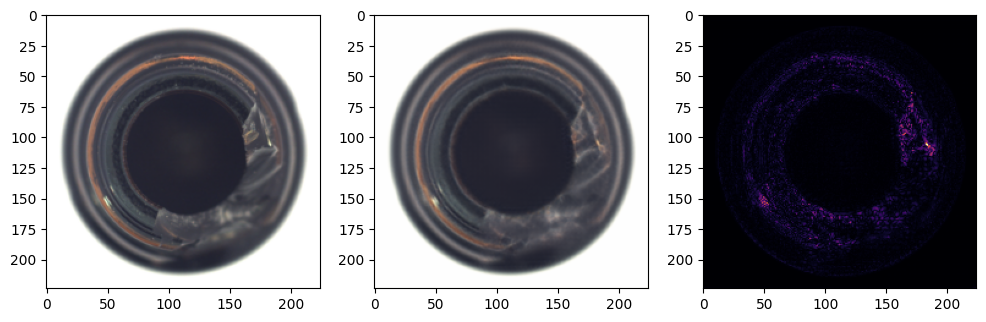

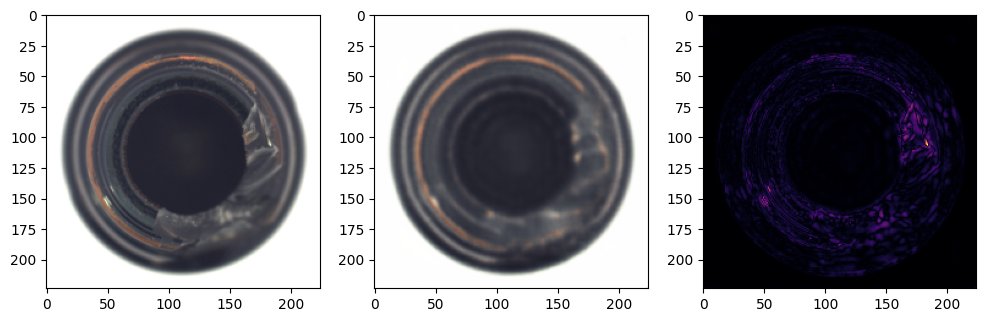

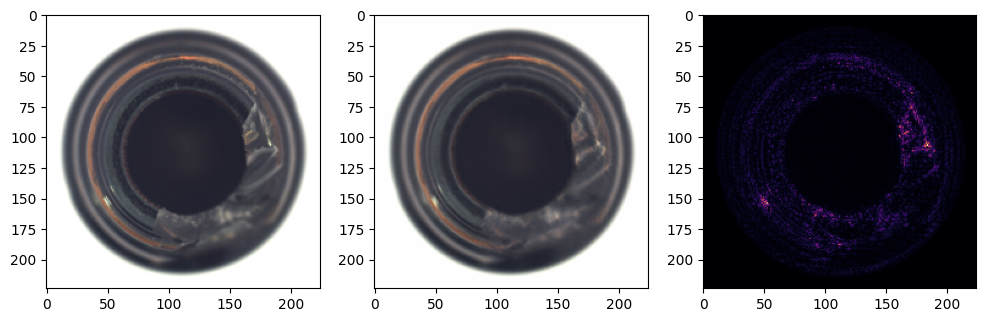

In [179]:
compare_img(test_images[1][0], trained_models[0].cpu())
compare_img(test_images[0][0], trained_models[1].cpu())
compare_img(test_images[0][0], trained_models[2].cpu())
compare_img(test_images[0][0], trained_models[3].cpu())

# Patchcore

In [ ]:
# Must change 
# from timm.layers.drop import DropPath -> from timm.models.layers.drop import DropPath
import anomalib
from anomalib.deploy import ExportType
from anomalib.engine import Engine
from anomalib.models import Patchcore
from anomalib.data import Folder, PredictDataset
from anomalib.pre_processing import PreProcessor
from torchvision.transforms.v2 import Compose, Resize
from itertools import product
from anomalib.deploy import OpenVINOInferencer
from tabulate import tabulate

from lightning.pytorch.callbacks import TQDMProgressBar

datamodule = Folder(
    name=name_dataset,
    normal_dir=train_path,
    #abnormal_dir=test_path,
    train_batch_size=8,
    eval_batch_size=8,
    num_workers=0)

## Train

In [ ]:
num_neighbors_list = [2, 6, 10]
coreset_sampling_ratio_list = [0.001, 0.01, 0.1]
backbones_list = ["resnet50", "wide_resnet50_2"]

results = []
hyperparameters_list = list(product(coreset_sampling_ratio_list, backbones_list))
for ratio, backbone in tqdm(hyperparameters_list):

    model = Patchcore(backbone=backbone,
                      coreset_sampling_ratio=ratio,
                      visualizer=False)
    engine = Engine(max_epochs=1, enable_progress_bar=False, logger=False)
    engine.fit(datamodule=datamodule, model=model)

    for k in num_neighbors_list:
        model.model.num_neighbors = k
        results.append({"backbone": backbone, "ratio": ratio,
                        "k": k})
        engine.export(model=model,
                      model_file_name=f"PatchCore_{k}_{ratio}_{backbone}",
                      export_type=ExportType.OPENVINO)

    del model, engine
    torch.mps.empty_cache()
    torch.cuda.empty_cache()

  0%|          | 0/6 [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/joaofranciscoviana/miniconda3/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │  8.5 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 8.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.5 M                                                                                                
Total estimated model params size (MB): 34.173                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 148                                                                                          
Total FLOPs: 0

/Users/joaofranciscoviana/miniconda3/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/joaofranciscoviana/miniconda3/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/joaofranciscoviana/miniconda3/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/joaofranciscoviana/miniconda3/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 148 modul

...

Trainable params: 8.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.5 M                                                                                                
Total estimated model params size (MB): 34.173                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 148                                                                                          
Total FLOPs: 0

Selecting Coreset Indices.: 100%|██████████| 17202/17202 [11:46<00:00, 24.33it/s]
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99.450                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 148                                                                                          
Total FLOPs: 0

Selecting Coreset Indices.: 100%|██████████| 17202/17202 [12:34<00:00, 22.79it/s]
`Trainer.fit` stopped: `max_epochs=1` reached.


## Results

In [63]:
num_neighbors_list = [2, 6, 10]
coreset_sampling_ratio_list = [0.001, 0.01, 0.1]
backbones_list = ["resnet50", "wide_resnet50_2"]

counter=-1

patchcore_results = []

for coreset_sampling_ratio, backbone in tqdm(list(product(coreset_sampling_ratio_list, backbones_list))):
    counter+=1

    for num_neighbors in num_neighbors_list: 
        model_name = "PatchCore_" + str(num_neighbors) + "_" + str(coreset_sampling_ratio) + "_" + backbone
        model_path = "results/Patchcore/" + name_dataset + "/v" + str(counter) + "/weights/openvino/" + model_name + ".bin"

        inferencer = OpenVINOInferencer(
            path=model_path,)

        print("----------------------------------------------------------\n",counter, model_name, "|", model_path)
        y_pred = []
        y_true = []
        for filename in os.listdir(test_path):
            if os.path.isdir(os.path.join(test_path,filename)):
                #print(filename)
                dataset = PredictDataset(
                    path=test_path + filename,
                    image_size=(img_size, img_size))
                for img in dataset:
                    #print(img.image)
                    prediction = inferencer.predict(image=img.image)
                    y_pred.append(prediction.pred_score)
                    y_true.append(0 if filename == "good" else 1)


        # Calculate ROC
        
        model_roc_curve = roc_curve(y_true, y_pred)
        fpr, tpr, thresholds = model_roc_curve
        roc_auc = auc(fpr, tpr)
        print(roc_auc)

        # Save
        results = {"model_name" : model_name,
            "roc" : model_roc_curve,
            "y_pred" : y_pred,
            "y_true" : y_true}

        patchcore_results.append(results)


  0%|          | 0/6 [00:00<?, ?it/s]

----------------------------------------------------------
 0 PatchCore_2_0.001_resnet50 | results/Patchcore/bottle/v0/weights/openvino/PatchCore_2_0.001_resnet50.bin
0.6730158730158731
----------------------------------------------------------
 0 PatchCore_6_0.001_resnet50 | results/Patchcore/bottle/v0/weights/openvino/PatchCore_6_0.001_resnet50.bin
0.5
----------------------------------------------------------
 0 PatchCore_10_0.001_resnet50 | results/Patchcore/bottle/v0/weights/openvino/PatchCore_10_0.001_resnet50.bin
0.5
----------------------------------------------------------
 1 PatchCore_2_0.001_wide_resnet50_2 | results/Patchcore/bottle/v1/weights/openvino/PatchCore_2_0.001_wide_resnet50_2.bin
0.9285714285714286
----------------------------------------------------------
 1 PatchCore_6_0.001_wide_resnet50_2 | results/Patchcore/bottle/v1/weights/openvino/PatchCore_6_0.001_wide_resnet50_2.bin
1.0
----------------------------------------------------------
 1 PatchCore_10_0.001_wide

In [129]:
counter=0

table = []
for model in patchcore_results:
    model_name = model["model_name"]

    num_neighbors, coreset_sampling_ratio, backbone = model_name.split("_")[1:4]

    fpr, tpr, thresholds = model["roc"]
    roc_auc = auc(fpr, tpr)

    y_true = np.array(model["y_true"]).flatten()
    y_pred = np.array(model["y_pred"]).flatten()

    lowest_anomaly = 1.
    highest_nominal = 0.

    for y, p in zip(y_true, y_pred):
        if y == 0:
            highest_nominal = max([p, highest_nominal])
            
        elif y == 1:
            lowest_anomaly = min([p, lowest_anomaly])
        else:
            print("Something went wrong.")
   
    table.append([counter, lowest_anomaly - highest_nominal,  roc_auc,  num_neighbors, coreset_sampling_ratio, backbone])
    counter += 1

print(tabulate(table, headers=["id", "separation", "roc", "neightbors", "coreset_ratio", "backbone"]))

  id    separation       roc    neightbors    coreset_ratio  backbone
----  ------------  --------  ------------  ---------------  ----------
   0     -1         0.673016             2            0.001  resnet50
   1      0         0.5                  6            0.001  resnet50
   2      0         0.5                 10            0.001  resnet50
   3     -0.297607  0.928571             2            0.001  wide
   4      0.487549  1                    6            0.001  wide
   5      0.499756  1                   10            0.001  wide
   6     -0.323975  0.993651             2            0.01   resnet50
   7      0.26123   1                    6            0.01   resnet50
   8      0.273926  1                   10            0.01   resnet50
   9     -0.25293   0.975397             2            0.01   wide
  10      0.27124   1                    6            0.01   wide
  11      0.295166  1                   10            0.01   wide
  12     -0.65332   0.902381             2